# Customer Churn Prediction 

In [1]:
# importing required libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# reading csv file
df = pd.read_csv(r"C:\Users\agraw\OneDrive\Desktop\customer_churn.zip")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# printing shape of dataset
df.shape

(7043, 21)

In [4]:
# printing names of columns of dataset
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [5]:
# checking information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
# checking for null values in dataset
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
# describing dataset
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
# checking for duplicate values in dataset
df.duplicated().sum()

np.int64(0)

In [9]:
# checking unique values in a column
df["customerID"].unique()

array(['7590-VHVEG', '5575-GNVDE', '3668-QPYBK', ..., '4801-JZAZL',
       '8361-LTMKD', '3186-AJIEK'], shape=(7043,), dtype=object)

In [10]:
# dropping unnecessary column from dataset
df.drop(columns = "customerID", inplace = True)

In [11]:
# checking unique values in a column
df["InternetService"].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

In [12]:
# checking unique values in a column
df["PaymentMethod"].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

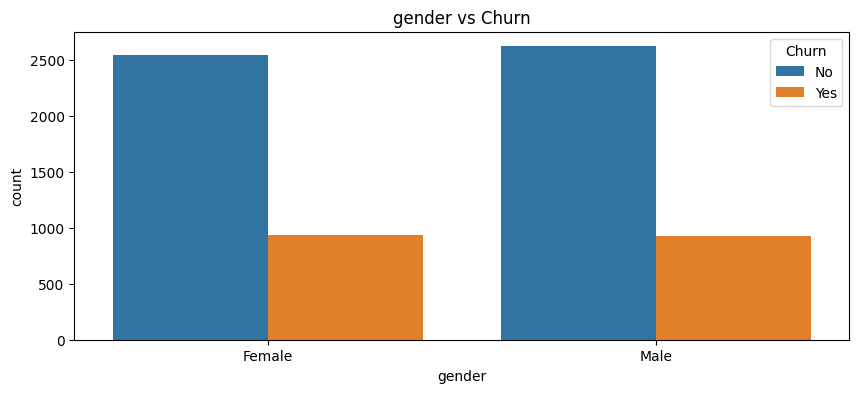

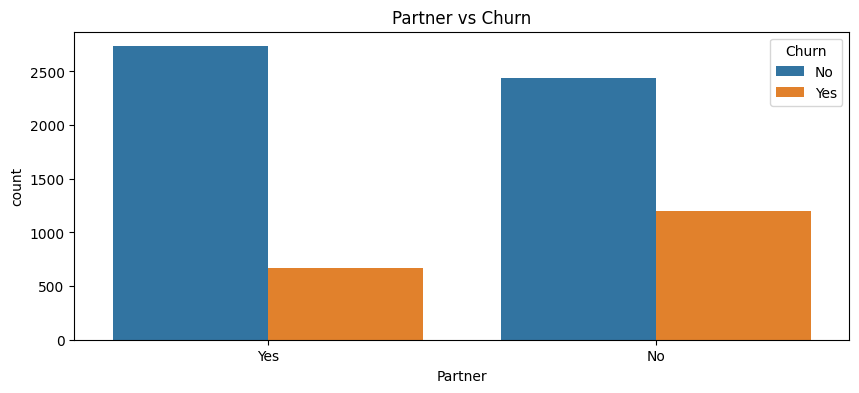

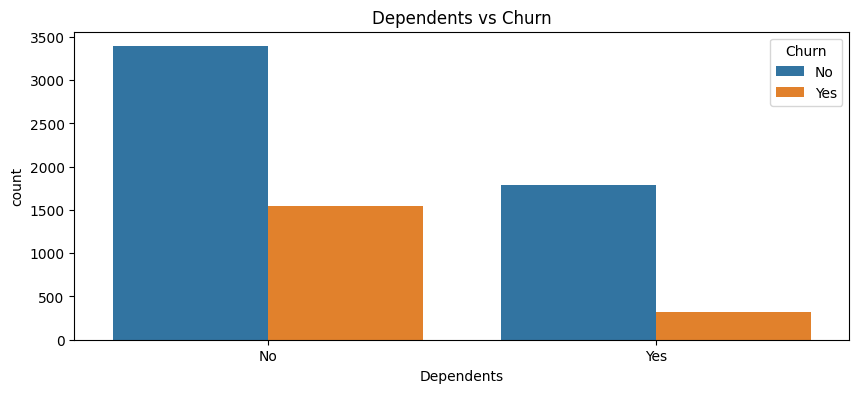

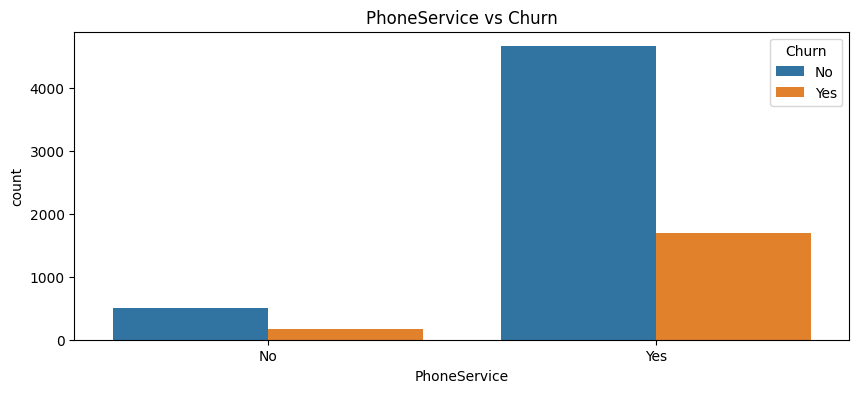

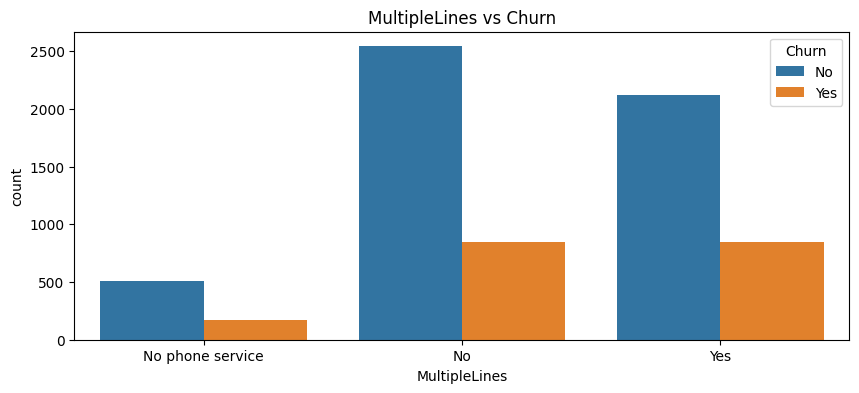

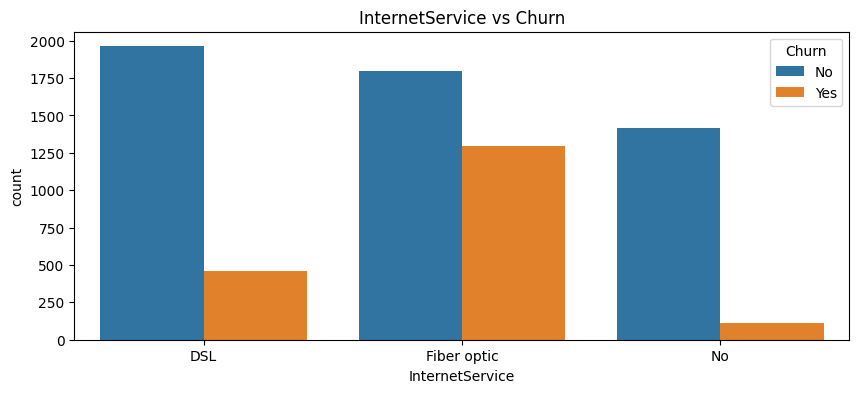

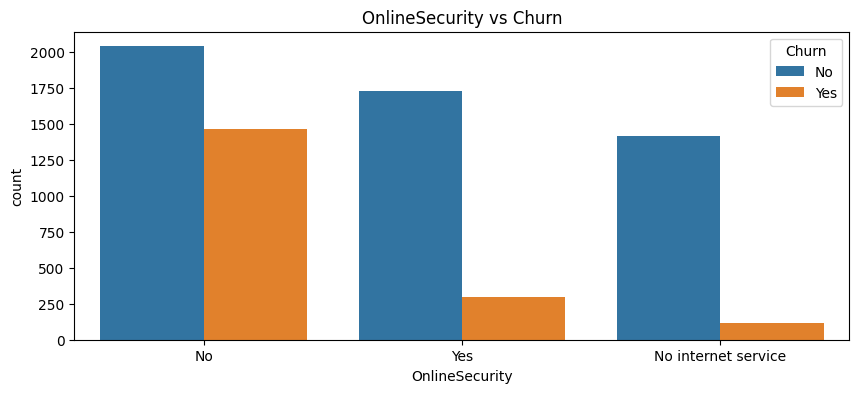

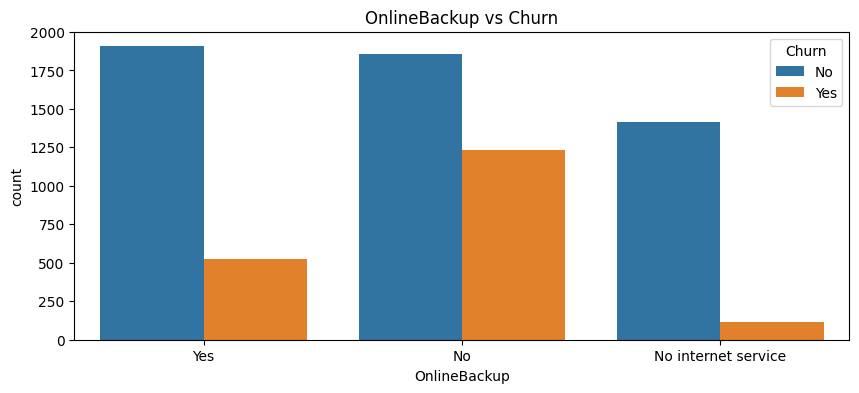

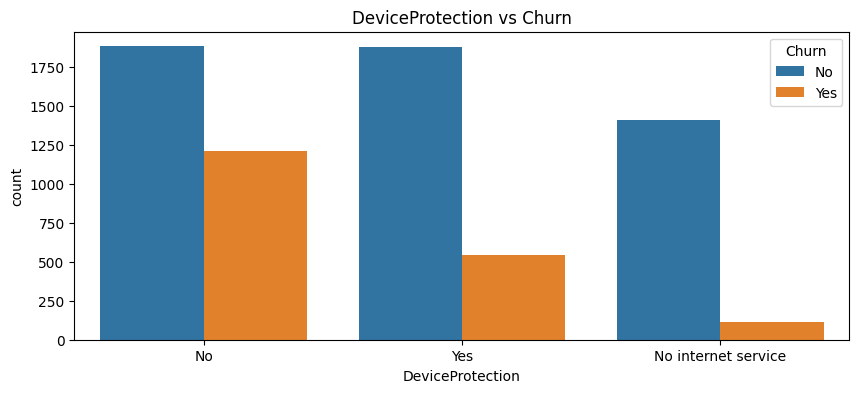

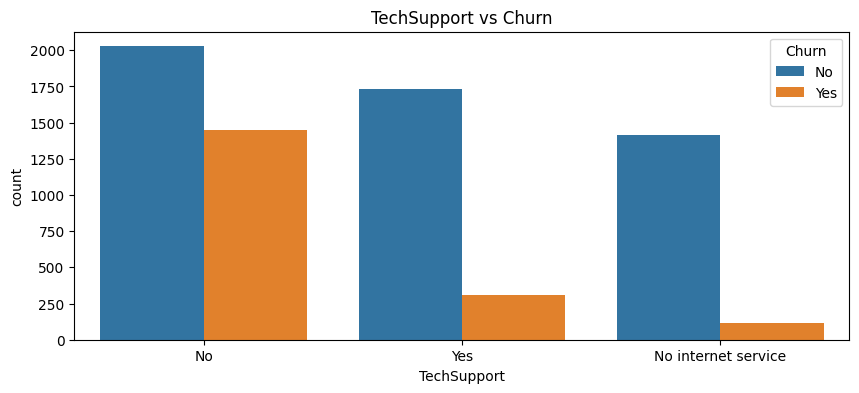

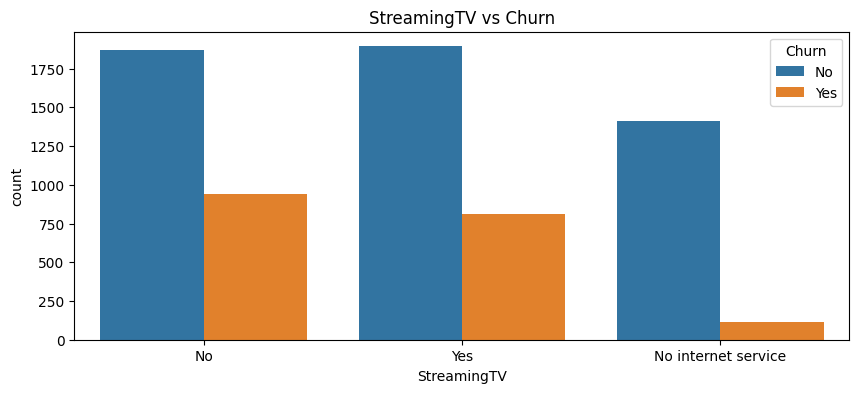

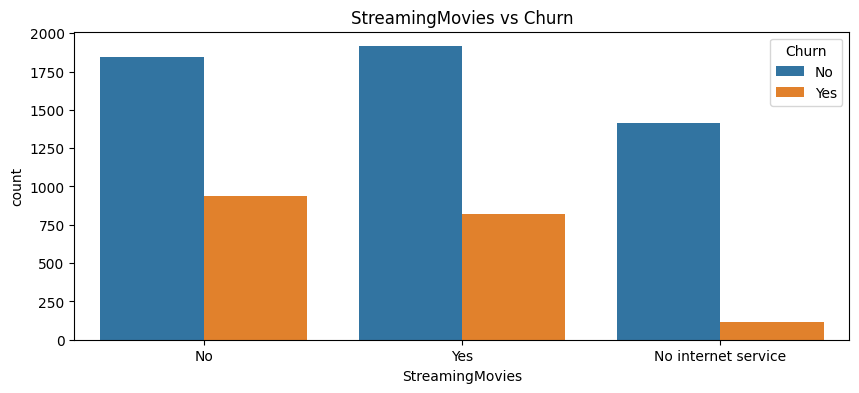

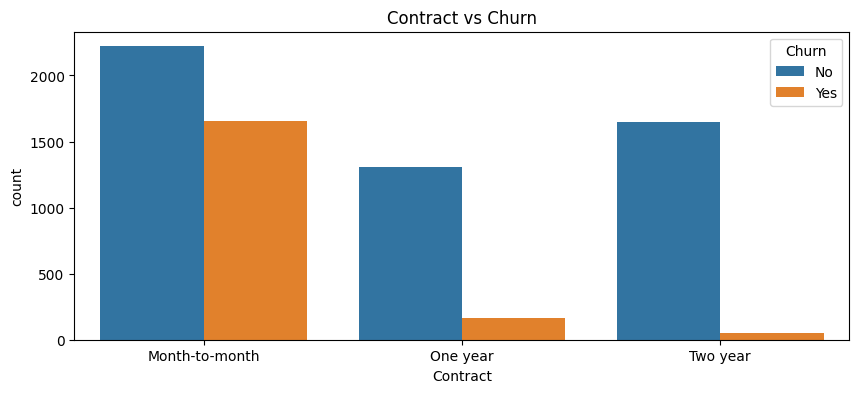

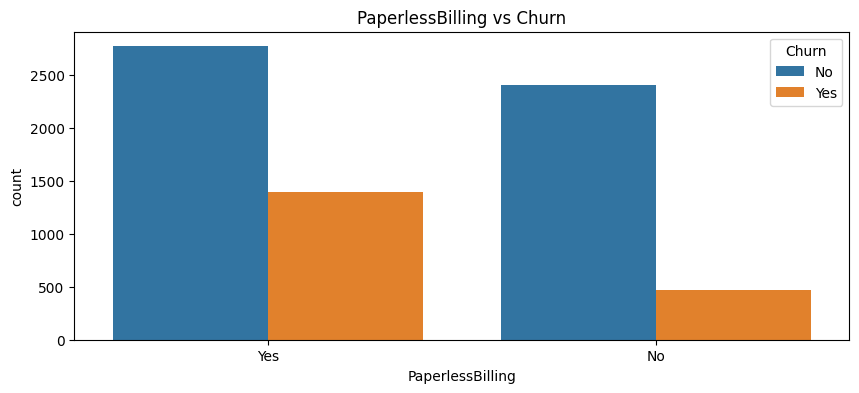

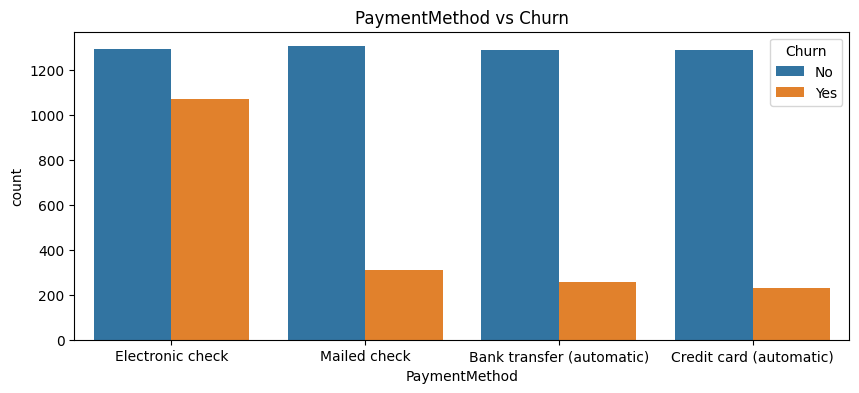

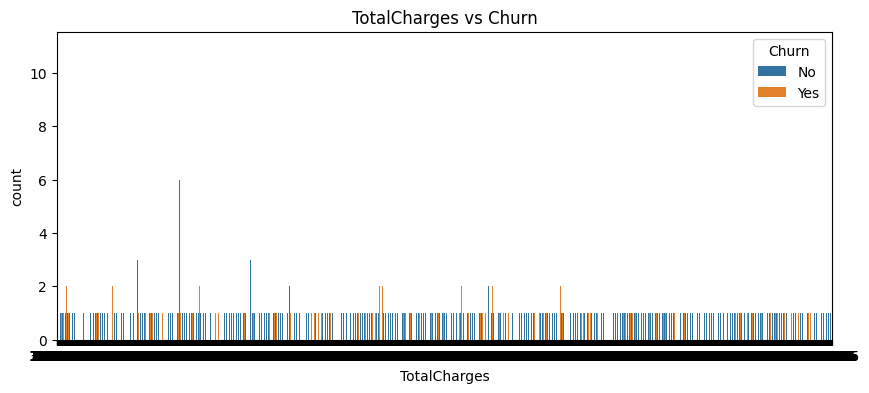

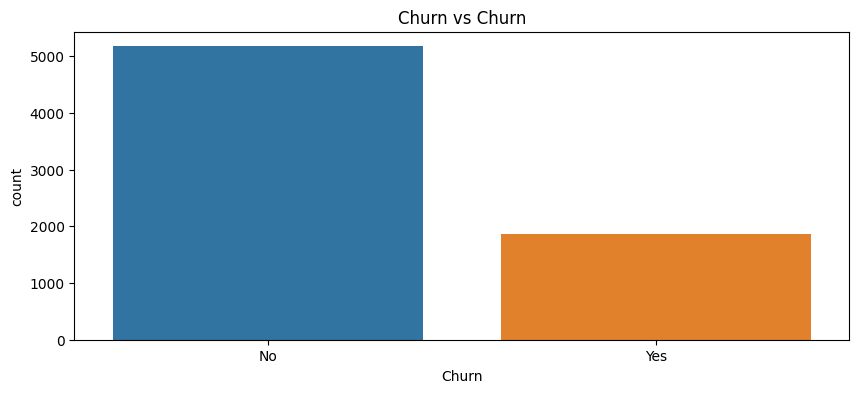

In [13]:
# analysing the trend of object type of properties with the output property
for i in df.select_dtypes(include = "object").columns:
    plt.figure(figsize = (10,4))
    sns.countplot(x=i, hue='Churn', data=df)
    plt.title(i+" "+"vs Churn")
    plt.show()

In [14]:
df["Churn"] = pd.get_dummies(df["Churn"], drop_first = True, dtype = "int64")

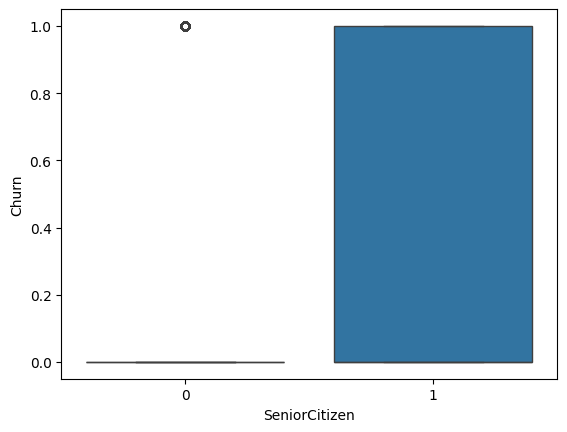

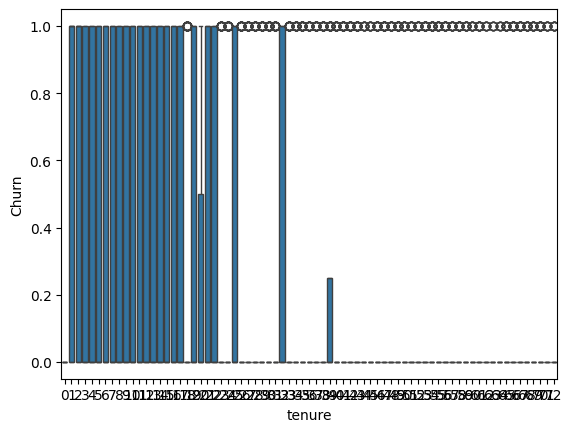

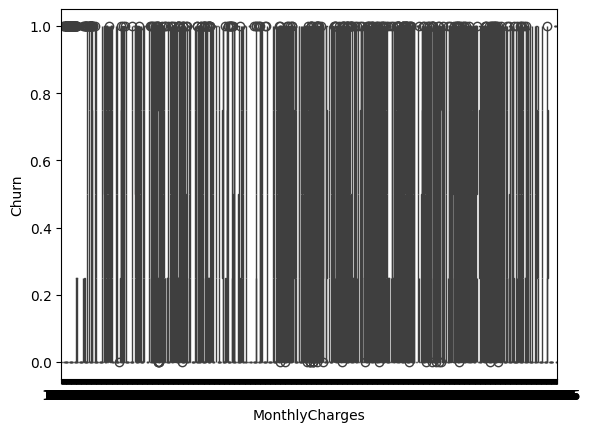

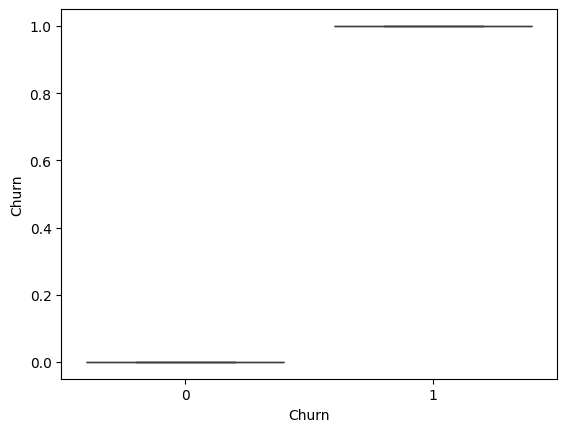

In [15]:
# plotting boxplot 
for i in df.select_dtypes(include = ["float64", "int64"]).columns:
    sns.boxplot(x=df[i],  y = df["Churn"])
    plt.show()

In [16]:
# dropping unnecessary column from dataset
df.drop(columns = "TotalCharges", inplace = True)

In [17]:
# collecting names of object dtypes column name in a list
object_columns = df.select_dtypes(include = "object").columns
object_columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [18]:
# printing unique values of each object type of column
for i in object_columns:
    print(i, df[i].unique())

gender ['Female' 'Male']
Partner ['Yes' 'No']
Dependents ['No' 'Yes']
PhoneService ['No' 'Yes']
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling ['Yes' 'No']
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [19]:
col1 = ["gender", "Partner", "Dependents", "PhoneService", "PaperlessBilling"]

In [20]:
# encoding of  object type of columns using get dummies method of pandas
for i in col1:
    df[i] = pd.get_dummies(df[i], drop_first = True, dtype = "int64")


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   object 


In [22]:
# printing unique values of each object type of column
for i in object_columns:
    print(i, df[i].unique())

gender [0 1]
Partner [1 0]
Dependents [0 1]
PhoneService [0 1]
MultipleLines ['No phone service' 'No' 'Yes']
InternetService ['DSL' 'Fiber optic' 'No']
OnlineSecurity ['No' 'Yes' 'No internet service']
OnlineBackup ['Yes' 'No' 'No internet service']
DeviceProtection ['No' 'Yes' 'No internet service']
TechSupport ['No' 'Yes' 'No internet service']
StreamingTV ['No' 'Yes' 'No internet service']
StreamingMovies ['No' 'Yes' 'No internet service']
Contract ['Month-to-month' 'One year' 'Two year']
PaperlessBilling [1 0]
PaymentMethod ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [23]:
# encoding of object type of column using map function of pandas
df["MultipleLines"] = df["MultipleLines"].map({"No phone service" : 0, "No" : 1, "Yes" : 2})
df["InternetService"] = df["InternetService"].map({"DSL" :0 , "No" : 1, "Fiber optic" : 2})
df["OnlineSecurity"] = df["OnlineSecurity"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["OnlineBackup"] = df["OnlineBackup"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["DeviceProtection"] = df["DeviceProtection"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["TechSupport"] = df["TechSupport"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["StreamingTV"] = df["StreamingTV"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["StreamingMovies"] = df["StreamingMovies"].map({"Yes" : 0, "No" : 1, "No internet service" : 3})
df["Contract"] = df["Contract"].map({"Month-to-month" : 0, "One year" : 1, "Two year" : 2})
df["PaymentMethod"] = df["PaymentMethod"].map({"Electronic check" : 0, "Mailed check" : 1, "Bank transfer (automatic)" : 2, 'Credit card (automatic)' : 3})

In [24]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   int64  
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   int64  
 3   Dependents        7043 non-null   int64  
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   int64  
 6   MultipleLines     7043 non-null   int64  
 7   InternetService   7043 non-null   int64  
 8   OnlineSecurity    7043 non-null   int64  
 9   OnlineBackup      7043 non-null   int64  
 10  DeviceProtection  7043 non-null   int64  
 11  TechSupport       7043 non-null   int64  
 12  StreamingTV       7043 non-null   int64  
 13  StreamingMovies   7043 non-null   int64  
 14  Contract          7043 non-null   int64  
 15  PaperlessBilling  7043 non-null   int64  
 16  PaymentMethod     7043 non-null   int64  


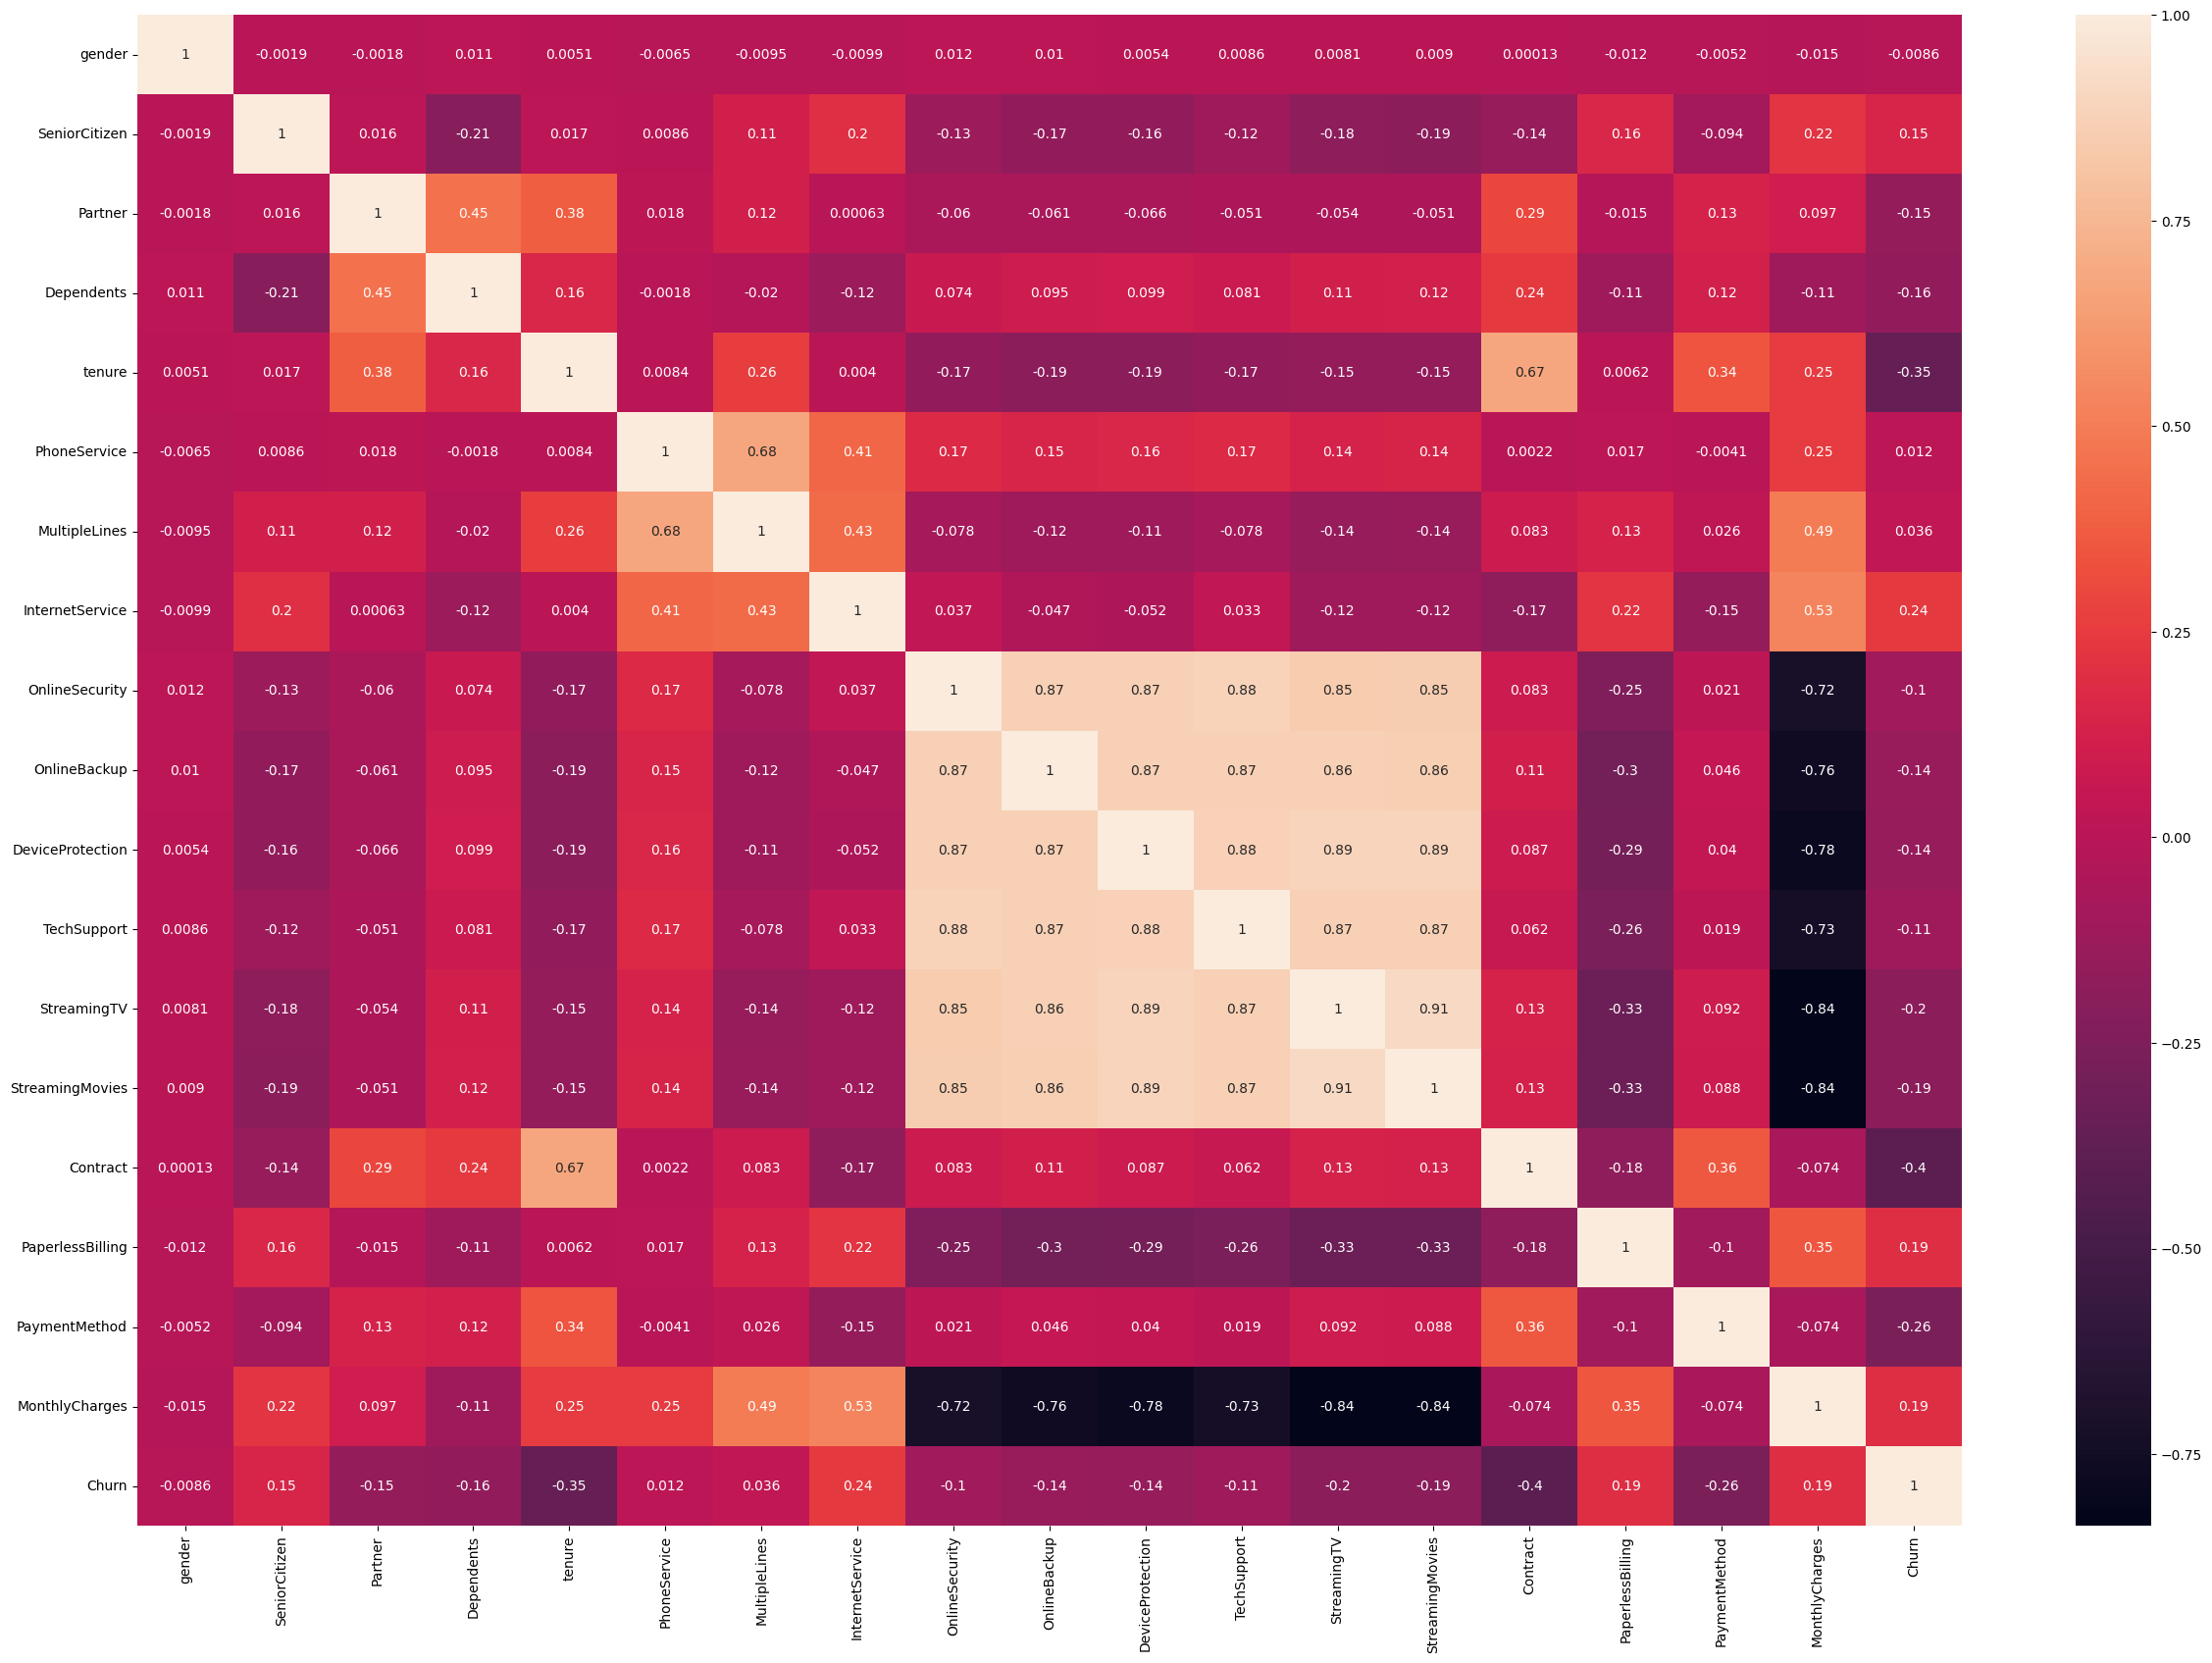

In [25]:
# plotting heatmap to find correlation
plt.figure(figsize=(30, 20))
sns.heatmap(df.corr(), annot = True)
plt.show()

In [26]:
# dropping unnecessary columns form dataset
df.drop(columns = ["gender", "PhoneService", "MultipleLines"], inplace = True)

In [27]:
# counting values in target column
df["Churn"].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [28]:
df.columns

Index(['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'Churn'],
      dtype='object')

In [29]:
# splitting , training data
x = df[['SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges']]
y = df['Churn']
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.25, random_state= 42)

In [30]:
# standardization of testing and training data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [31]:
# resampling of imbalance output data using smote
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [32]:
print(y_train.value_counts())
print("\nAfter SMOTE:\n")
print(y_train_smote.value_counts())

Churn
0    3892
1    1390
Name: count, dtype: int64

After SMOTE:

Churn
1    3892
0    3892
Name: count, dtype: int64


In [33]:
# applying logistic regression algorithm 
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(class_weight = "balanced", max_iter = 5000)
lr.fit(x_train_smote, y_train_smote)

# printing score
print(lr.score(x_test, y_test)*100, lr.score(x_train_smote, y_train_smote)*100)

76.43384440658717 76.56731757451182


In [34]:
# finding accuracy score, confusion matrix analysis, classification report preparing
y_pred = lr.predict(x_test)
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100)

76.43384440658717


In [35]:
# printing confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[956, 326],
       [ 89, 390]])

In [36]:
# Accuracy score and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100, classification_report(y_test, y_pred)*100)

76.43384440658717               precision    recall  f1-score   support

           0       0.91      0.75      0.82      1282
           1       0.54      0.81      0.65       479

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.74      1761
weighted avg       0.81      0.76      0.78      1761
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1282
           1       0.54      0.81      0.65       479

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.74      1761
weighted avg       0.81      0.76      0.78      1761
              precision    recall  f1-score   support

           0       0.91      0.75      0.82      1282
           1       0.54      0.81      0.65       479

    accuracy                           0.76      1761
   macro avg       0.73      0.78      0.74      1761
weighted avg       0.81      0.76      0.78      1761
    

In [37]:
# Decision Tree Model
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(max_depth=5,random_state=42)
dt.fit(x_train_smote, y_train_smote)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current no

In [38]:
# Prediction
y_pred = dt.predict(x_test)

In [39]:
# Accuracy score and confusion matrix
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
print(accuracy_score(y_test, y_pred)*100, classification_report(y_test, y_pred)*100)

77.56956274843839               precision    recall  f1-score   support

           0       0.88      0.80      0.84      1282
           1       0.57      0.72      0.63       479

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.80      0.78      0.78      1761
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1282
           1       0.57      0.72      0.63       479

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.80      0.78      0.78      1761
              precision    recall  f1-score   support

           0       0.88      0.80      0.84      1282
           1       0.57      0.72      0.63       479

    accuracy                           0.78      1761
   macro avg       0.73      0.76      0.74      1761
weighted avg       0.80      0.78      0.78      1761
    

<Axes: >

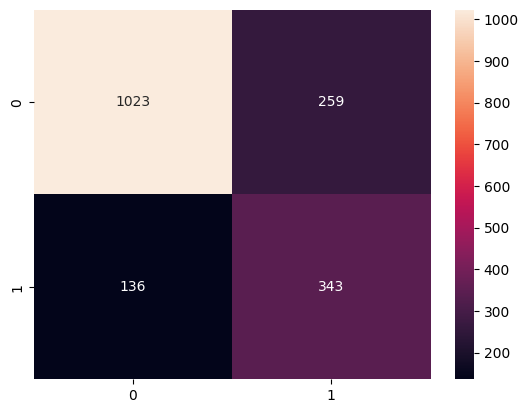

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm
sns.heatmap(cm, annot=True, fmt='d')

In [41]:
# random forest classifier
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(x_train_smote, y_train_smote)

y_pred = model.predict(x_test)

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(accuracy)

0.787052810902896


<Axes: >

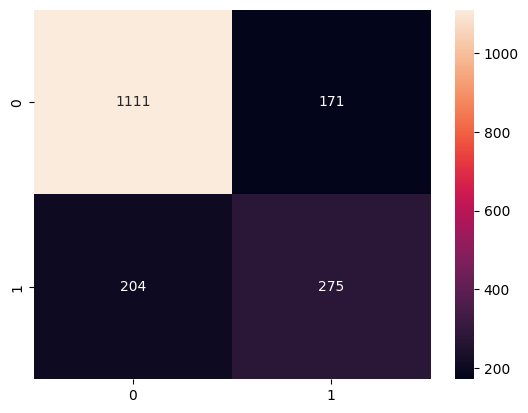

In [42]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
cm
sns.heatmap(cm, annot=True, fmt='d')

In [43]:
# Accuracy score and confusion matrix
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred)*100)

              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1282
           1       0.62      0.57      0.59       479

    accuracy                           0.79      1761
   macro avg       0.73      0.72      0.73      1761
weighted avg       0.78      0.79      0.78      1761
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1282
           1       0.62      0.57      0.59       479

    accuracy                           0.79      1761
   macro avg       0.73      0.72      0.73      1761
weighted avg       0.78      0.79      0.78      1761
              precision    recall  f1-score   support

           0       0.84      0.87      0.86      1282
           1       0.62      0.57      0.59       479

    accuracy                           0.79      1761
   macro avg       0.73      0.72      0.73      1761
weighted avg       0.78      0.79      0.78      1761
              precisio